In [1]:
import pandas as pd

folder = "store-sales-time-series-forecasting"

train = pd.read_csv(f"{folder}/train.csv")
test = pd.read_csv(f"{folder}/test.csv")
stores = pd.read_csv(f"{folder}/stores.csv")
oil = pd.read_csv(f"{folder}/oil.csv")
holidays = pd.read_csv(f"{folder}/holidays_events.csv")
transactions = pd.read_csv(f"{folder}/transactions.csv")

In [2]:
print(train.shape)
print(test.shape)
print(stores.shape)
print(oil.shape)
print(holidays.shape)
print(transactions.shape)

(3000888, 6)
(28512, 5)
(54, 5)
(1218, 2)
(350, 6)
(83488, 3)


In [3]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [5]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


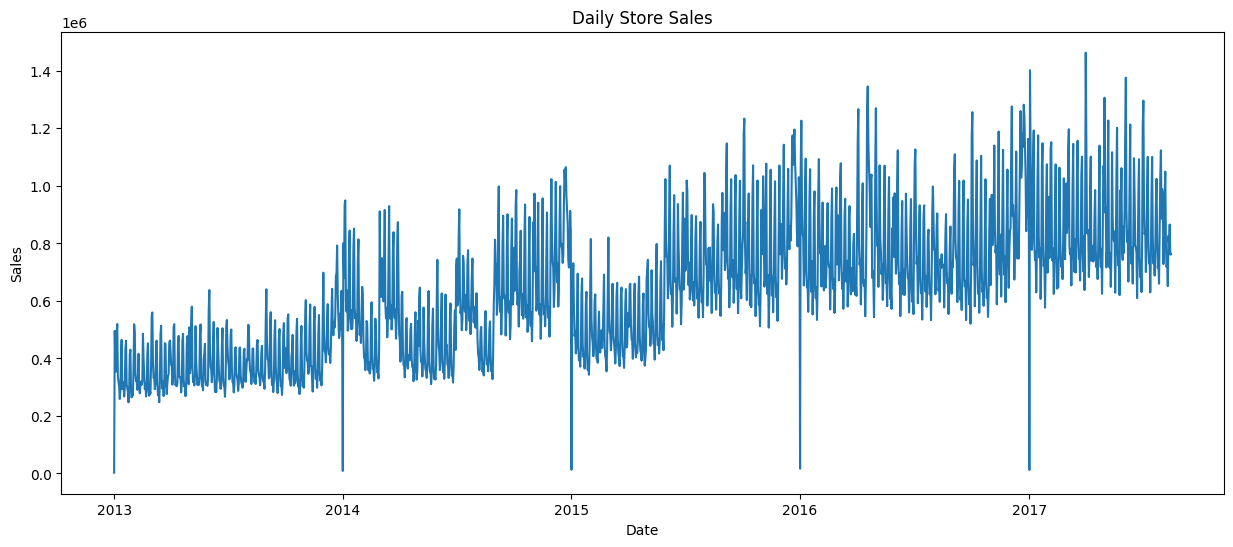

In [6]:
import matplotlib.pyplot as plt

train['date'] = pd.to_datetime(train['date'])

daily_sales = (
    train.groupby('date')['sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,6))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Daily Store Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

Find the biggest product families

In [7]:
family_sales = (
    train.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(family_sales.head(10))

family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64


Grocery, Beverages and Produce collectively account for the majority of sales volume, indicating that forecasting accuracy improvements in these categories would generate the greatest business impact. These categories should be prioritized for demand planning and inventory optimization initiatives.

Find the biggest stores

In [8]:
store_sales = (
    train.groupby('store_nbr')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(store_sales.head(10))

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
Name: sales, dtype: float64


In [9]:
forecast_df = (
    train.groupby('date')['sales']
    .sum()
    .reset_index()
)

In [10]:
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


We have 3million rows.

In [11]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

No missing values

In [12]:
train.duplicated().sum()

0

No duplicate rows

In [13]:
train['sales'].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [14]:
(train['sales'] == 0).sum()

939130

In [15]:
939130 / 3000888 * 100

31.29506999261552

31.3% meaning nearly 1/3 of store-product-day combinations recorded no sales.

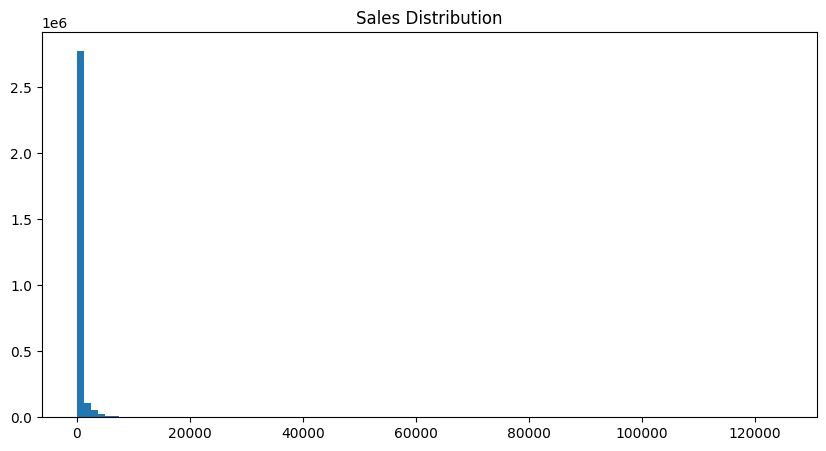

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(
    train['sales'],
    bins=100
)
plt.title("Sales Distribution")
plt.show()

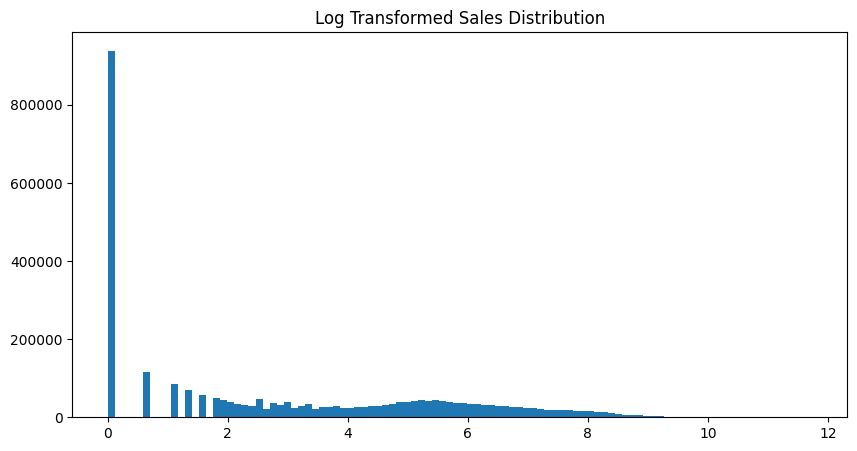

In [17]:
import numpy as np

plt.figure(figsize=(10,5))
plt.hist(
    np.log1p(train['sales']),
    bins=100
)
plt.title("Log Transformed Sales Distribution")
plt.show()

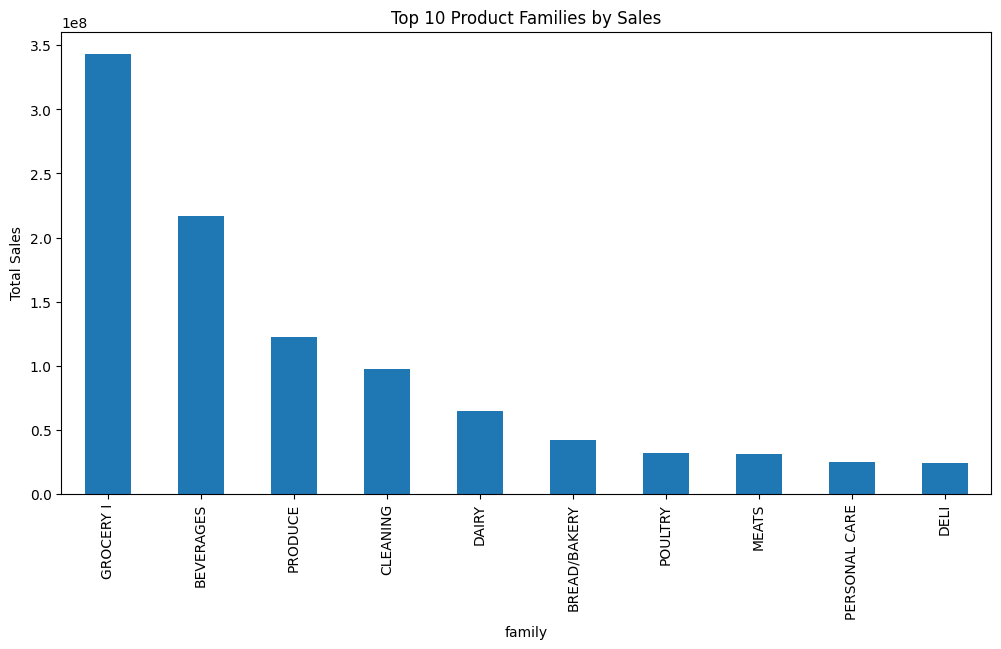

In [18]:
import matplotlib.pyplot as plt

family_sales.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 10 Product Families by Sales')
plt.ylabel('Total Sales')
plt.show()

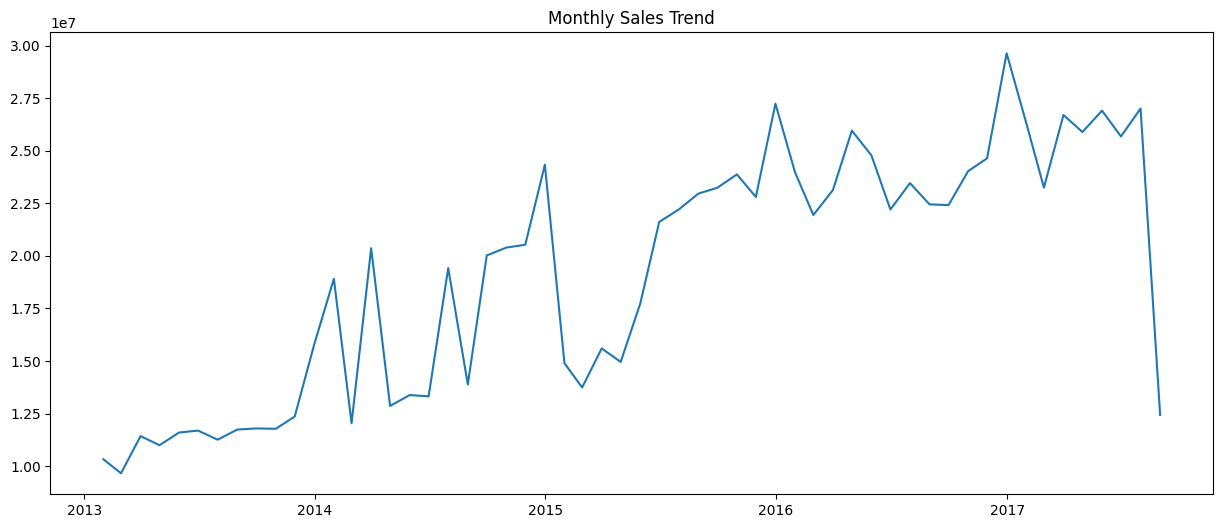

In [19]:
monthly_sales = (
    daily_sales
    .set_index('date')
    .resample('ME')
    .sum()
)
plt.figure(figsize=(15,6))
plt.plot(monthly_sales.index,
         monthly_sales['sales'])

plt.title('Monthly Sales Trend')
plt.show()

#### Forecast Dataset 

In [20]:
grocery = train[
    train['family'] == 'GROCERY I'
].copy()

In [21]:
grocery_daily = (
    grocery.groupby('date')['sales']
    .sum()
    .reset_index()
)

In [22]:
grocery_daily.head()

,date,sales
0,2013-01-01,700.0
1,2013-01-02,202020.0
2,2013-01-03,144878.0
3,2013-01-04,135754.0
4,2013-01-05,188356.0


Plot Grocery Trend

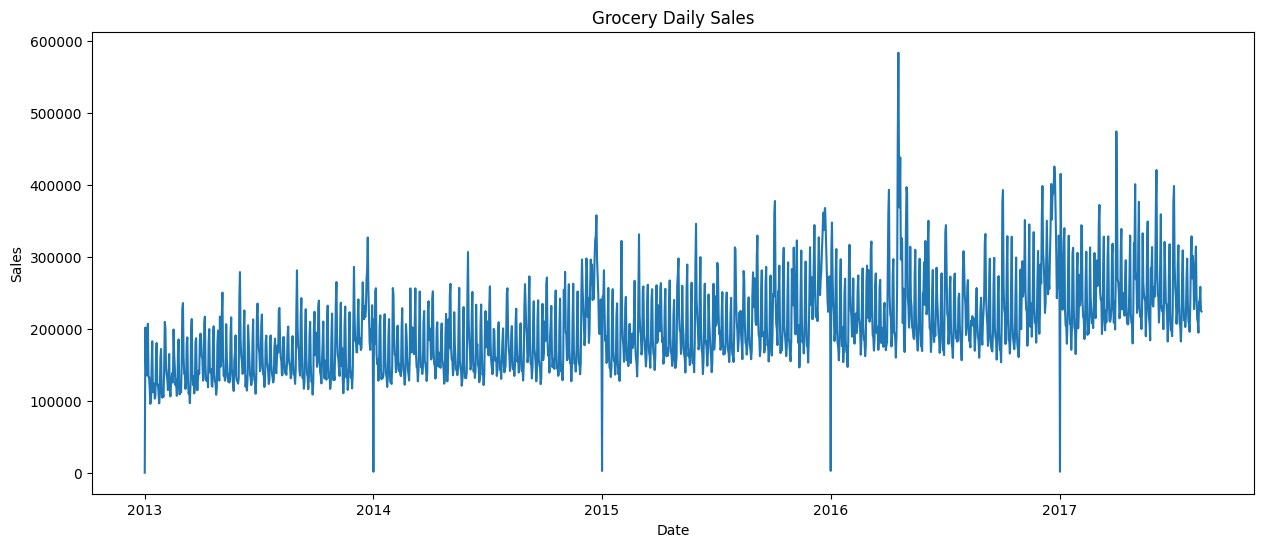

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    grocery_daily['date'],
    grocery_daily['sales']
)

plt.title('Grocery Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

Lag 7

In [24]:
grocery_daily['lag_7'] = (
    grocery_daily['sales']
    .shift(7)
)

Lag 14

In [25]:
grocery_daily['lag_14'] = (
    grocery_daily['sales']
    .shift(14)
)

Lag 28

In [26]:
grocery_daily['lag_28'] = (
    grocery_daily['sales']
    .shift(28)
)

Rolling Mean

In [27]:
grocery_daily['rolling_7'] = (
    grocery_daily['sales']
    .rolling(7)
    .mean()
)

Day of Week

In [28]:
grocery_daily['dayofweek'] = (
    grocery_daily['date']
    .dt.dayofweek
)

Month

In [29]:
grocery_daily['month'] = (
    grocery_daily['date']
    .dt.month
)

Check Features

In [30]:
grocery_daily.head(15)

,date,sales,lag_7,lag_14,lag_28,rolling_7,dayofweek,month
0,2013-01-01,700.0,NaN,NaN,NaN,NaN,1,1
1,2013-01-02,202020.0,NaN,NaN,NaN,NaN,2,1
2,2013-01-03,144878.0,NaN,NaN,NaN,NaN,3,1
3,2013-01-04,135754.0,NaN,NaN,NaN,NaN,4,1
4,2013-01-05,188356.0,NaN,NaN,NaN,NaN,5,1
5,2013-01-06,207297.0,NaN,NaN,NaN,NaN,6,1
6,2013-01-07,133189.0,NaN,NaN,NaN,144599.142857,0,1
7,2013-01-08,133290.0,700.0,NaN,NaN,163540.571429,1,1
8,2013-01-09,115871.0,202020.0,NaN,NaN,151233.571429,2,1
9,2013-01-10,96200.0,144878.0,NaN,NaN,144279.571429,3,1


In [31]:
grocery_daily.head(15)

,date,sales,lag_7,lag_14,lag_28,rolling_7,dayofweek,month
0,2013-01-01,700.0,NaN,NaN,NaN,NaN,1,1
1,2013-01-02,202020.0,NaN,NaN,NaN,NaN,2,1
2,2013-01-03,144878.0,NaN,NaN,NaN,NaN,3,1
3,2013-01-04,135754.0,NaN,NaN,NaN,NaN,4,1
4,2013-01-05,188356.0,NaN,NaN,NaN,NaN,5,1
5,2013-01-06,207297.0,NaN,NaN,NaN,NaN,6,1
6,2013-01-07,133189.0,NaN,NaN,NaN,144599.142857,0,1
7,2013-01-08,133290.0,700.0,NaN,NaN,163540.571429,1,1
8,2013-01-09,115871.0,202020.0,NaN,NaN,151233.571429,2,1
9,2013-01-10,96200.0,144878.0,NaN,NaN,144279.571429,3,1


In [32]:
holidays[
    holidays['date'] == '2013-01-01'
]

,date,type,locale,locale_name,description,transferred
41,2013-01-01,Holiday,National,Ecuador,Primer dia del ano,False


Holidays matters in forecasting. Low sales are real, not bad data.

Forecasting 2

Create forecast dataset

In [33]:
grocery44 = train[
    (train['family'] == 'GROCERY I') &
    (train['store_nbr'] == 44)
].copy()

Aggregate daily sales

In [34]:
grocery44_daily = (
    grocery44.groupby('date')['sales']
    .sum()
    .reset_index()
)

In [35]:
print(grocery44_daily.shape)
grocery44_daily.head()

(1684, 2)


,date,sales
0,2013-01-01,0.0
1,2013-01-02,10686.0
2,2013-01-03,7342.0
3,2013-01-04,7250.0
4,2013-01-05,10699.0


Visualize Trend

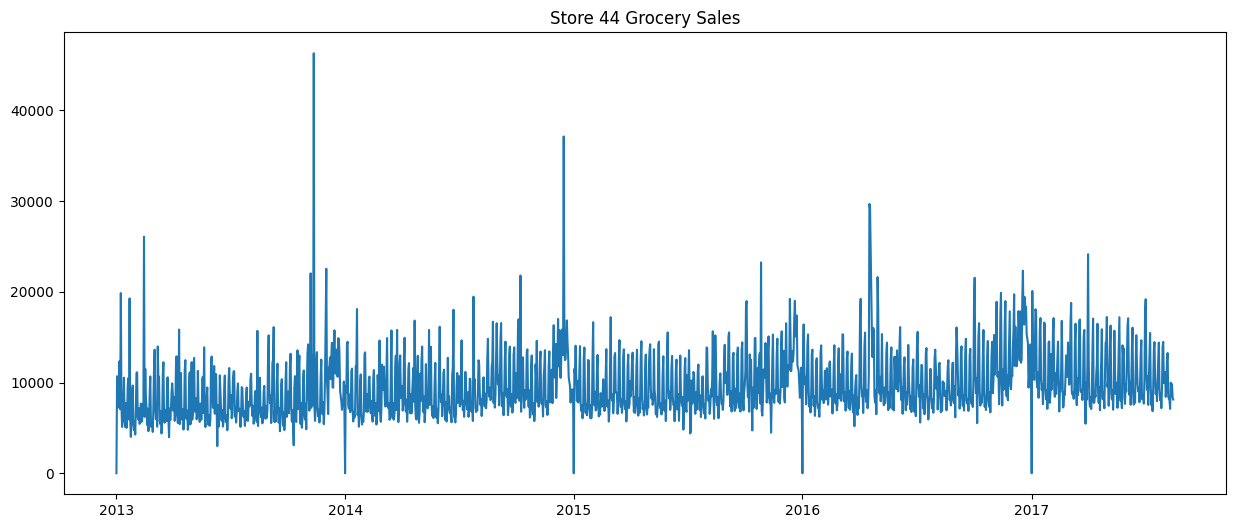

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    grocery44_daily['date'],
    grocery44_daily['sales']
)

plt.title('Store 44 Grocery Sales')
plt.show()

In [37]:
grocery44_daily['lag_7'] = grocery44_daily['sales'].shift(7)
grocery44_daily['lag_14'] = grocery44_daily['sales'].shift(14)
grocery44_daily['lag_28'] = grocery44_daily['sales'].shift(28)

grocery44_daily['rolling_7'] = (
    grocery44_daily['sales']
    .rolling(7)
    .mean()
)

grocery44_daily['rolling_30'] = (
    grocery44_daily['sales']
    .rolling(30)
    .mean()
)

grocery44_daily['dayofweek'] = (
    grocery44_daily['date']
    .dt.dayofweek
)

grocery44_daily['month'] = (
    grocery44_daily['date']
    .dt.month
)

Remove nulls

In [38]:
grocery44_daily = grocery44_daily.dropna()

Verify Features

In [39]:
grocery44_daily.head()

,date,sales,lag_7,lag_14,lag_28,rolling_7,rolling_30,dayofweek,month
29,2013-01-30,5669.0,5869.0,7737.0,10686.0,6309.000000,7921.400000,2,1
30,2013-01-31,4268.0,4007.0,4998.0,7342.0,6346.285714,8063.666667,3,1
31,2013-02-01,7265.0,5895.0,6000.0,7250.0,6542.000000,7949.633333,4,2
32,2013-02-02,11068.0,8709.0,9628.0,10699.0,6879.000000,8073.833333,5,2
33,2013-02-03,11125.0,9667.0,10488.0,12373.0,7087.285714,8203.000000,6,2


Holiday Flag

In [40]:
holiday_df = holidays[['date']].copy()

holiday_df['date'] = pd.to_datetime(
    holiday_df['date']
)

holiday_df['is_holiday'] = 1

holiday_df = holiday_df.drop_duplicates()

In [41]:
grocery44_daily = grocery44_daily.merge(
    holiday_df,
    on='date',
    how='left'
)

grocery44_daily['is_holiday'] = (
    grocery44_daily['is_holiday']
    .fillna(0)
)

In [42]:
holidays['type'].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [43]:
holiday_dates = holidays[['date']].drop_duplicates()

holiday_dates['date'] = pd.to_datetime(
    holiday_dates['date']
)

holiday_dates['is_holiday'] = 1

In [44]:
grocery44_daily['dayofmonth'] = (
    grocery44_daily['date']
    .dt.day
)

In [45]:
split_index = int(len(grocery44_daily) * 0.8)

train_df = grocery44_daily.iloc[:split_index]
test_df = grocery44_daily.iloc[split_index:]

In [46]:
features = [
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_7',
    'rolling_30',
    'dayofweek',
    'month',
    'dayofmonth',
    'is_holiday'
]

target = 'sales'

In [47]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

Train XGBoost

In [48]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

Predict

In [49]:
predictions = model.predict(X_test)

Evaluate

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 1505.54
RMSE: 2307.05
R²  : 0.5781


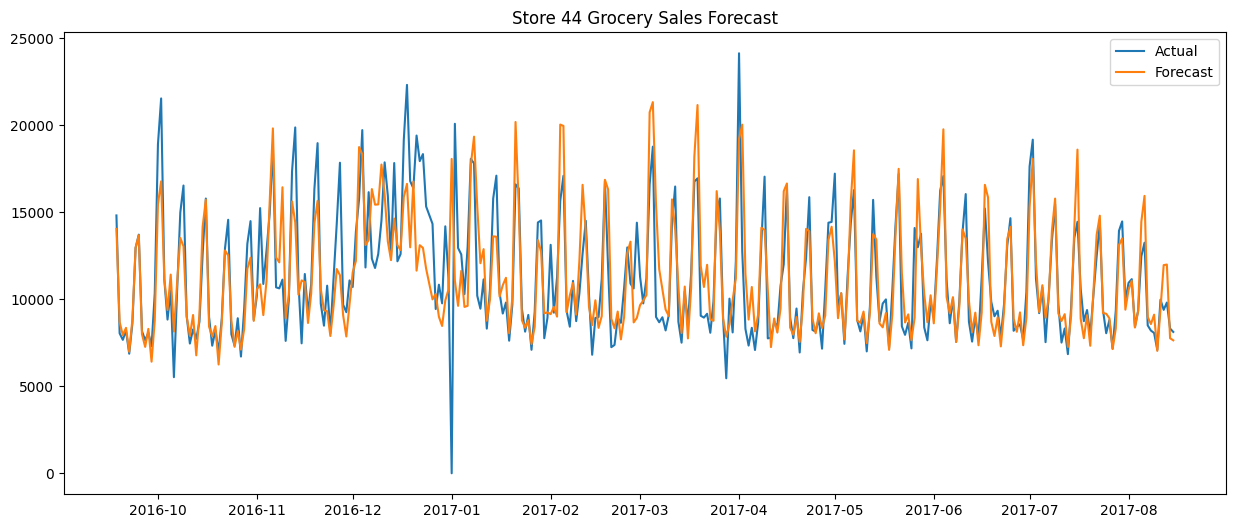

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    test_df['date'],
    y_test,
    label='Actual'
)

plt.plot(
    test_df['date'],
    predictions,
    label='Forecast'
)

plt.title('Store 44 Grocery Sales Forecast')
plt.legend()
plt.show()

What can we observe from the chart. 

1. Extreme Peak Underestimated. Actual around 24k, Forecast around 21k. Could be due to missing drivers such as Promotions, Holidays, Events, Transactions etc.
2. Jan 2017 Crash. Actual 0, Forecast 12k. The current features does not explain sudden closure or anomaly.

MAE : 1505.54
RMSE: 2307.05
R²  : 0.5781
Is R² good? 

<0.40  Weak
0.40-0.60 Reasonable
0.60-0.75 Good
0.75+ Strong

Next Step: Feature Importance

In [53]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

      Feature  Importance
5   dayofweek    0.587089
3   rolling_7    0.156031
4  rolling_30    0.057002
7  dayofmonth    0.046767
2      lag_28    0.037825
6       month    0.037080
1      lag_14    0.033484
0       lag_7    0.024358
8  is_holiday    0.020364


How to Improve R² 

1. Add Promotion feature
2. Add Transactions
3. Add Oil prices
4. Add Holiday type